In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Iris.csv")

# Kaggle Iris.csv에는 Id 컬럼이 있는 경우가 많아서, 있으면 제거
df = df.drop(columns=["Id"], errors="ignore")

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
print("총 붓꽃 데이터(행) 개수:", df.shape[0])
print("총 정보(열) 개수:", df.shape[1])

총 붓꽃 데이터(행) 개수: 150
총 정보(열) 개수: 5


In [ ]:
print(df.columns.tolist())

['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [ ]:
print("비어있는 값(null) 개수(열별):")
print(df.isna().sum())

numeric_cols = df.select_dtypes(include="number").columns
print("숫자 열 개수:", len(numeric_cols))
print("숫자 열 목록:", numeric_cols.tolist())

비어있는 값(null) 개수(열별):
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
숫자 열 개수: 4
숫자 열 목록: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


In [ ]:
print("SepalLengthCm 평균:", df["SepalLengthCm"].mean())
print("PetalWidthCm 최댓값:", df["PetalWidthCm"].max())

SepalLengthCm 평균: 5.843333333333334
PetalWidthCm 최댓값: 2.5


In [ ]:
species_counts = df["Species"].value_counts()
print("종류별 개수:")
print(species_counts)

print("세 종류의 개수가 같은가요?:", species_counts.nunique() == 1)

종류별 개수:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64
세 종류의 개수가 같은가요?: True


In [ ]:
print("PetalLengthCm > 2.0 인 데이터 개수:", (df["PetalLengthCm"] > 2.0).sum())

print("\nSepalWidthCm > 3.5 인 데이터(일부 5개):")
print(df[df["SepalWidthCm"] > 3.5].head())

PetalLengthCm > 2.0 인 데이터 개수: 100

SepalWidthCm > 3.5 인 데이터(일부 5개):
    SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
4             5.0           3.6            1.4           0.2  Iris-setosa
5             5.4           3.9            1.7           0.4  Iris-setosa
10            5.4           3.7            1.5           0.2  Iris-setosa
14            5.8           4.0            1.2           0.2  Iris-setosa
15            5.7           4.4            1.5           0.4  Iris-setosa


In [ ]:
# 실제 Iris 데이터의 표준 값 'Iris-versicolor'
mean_pl = df.loc[df["Species"] == "Iris-versicolor", "PetalLengthCm"].mean()
print("('Iris-versicolor'로 필터) 평균 PetalLengthCm:", mean_pl)

# virginica 최대 꽃받침 너비
max_sw = df.loc[df["Species"] == "Iris-virginica", "SepalWidthCm"].max()
print("Iris-virginica 최대 SepalWidthCm:", max_sw)

('Iris-versicolor'로 필터) 평균 PetalLengthCm: 4.26
Iris-virginica 최대 SepalWidthCm: 3.8


In [5]:
mean_table = df.groupby("Species")[["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]].mean()
print(mean_table)

print("꽃받침이 가장 긴 종류( SepalLengthCm 평균 기준 ):", mean_table["SepalLengthCm"].idxmax())
print("꽃잎이 가장 넓은 종류( PetalWidthCm 평균 기준 ):", mean_table["PetalWidthCm"].idxmax())

                 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
Species                                                                  
Iris-setosa              5.006         3.418          1.464         0.244
Iris-versicolor          5.936         2.770          4.260         1.326
Iris-virginica           6.588         2.974          5.552         2.026
꽃받침이 가장 긴 종류( SepalLengthCm 평균 기준 ): Iris-virginica
꽃잎이 가장 넓은 종류( PetalWidthCm 평균 기준 ): Iris-virginica


In [6]:
df["SepalArea"] = df["SepalLengthCm"] * df["SepalWidthCm"]
df["PetalArea"] = df["PetalLengthCm"] * df["PetalWidthCm"]

area_mean = df.groupby("Species")[["SepalArea","PetalArea"]].mean()
print(area_mean)

print("꽃받침 면적(SepalArea) 평균이 가장 큰 종류:", area_mean["SepalArea"].idxmax())
print("꽃잎 면적(PetalArea) 평균이 가장 큰 종류:", area_mean["PetalArea"].idxmax())

                 SepalArea  PetalArea
Species                              
Iris-setosa        17.2088     0.3628
Iris-versicolor    16.5262     5.7204
Iris-virginica     19.6846    11.2962
꽃받침 면적(SepalArea) 평균이 가장 큰 종류: Iris-virginica
꽃잎 면적(PetalArea) 평균이 가장 큰 종류: Iris-virginica


In [8]:
filtered_df = df[(df["SepalWidthCm"] >= 3.0) & (df["PetalWidthCm"] >= 1.5)]

print("조건 만족 데이터 개수:", len(filtered_df))
print("조건 만족 데이터(앞 5개):")
print(filtered_df.head())

print("주로 어떤 종류인가요?")
print(filtered_df["Species"].value_counts())

조건 만족 데이터 개수: 39
조건 만족 데이터(앞 5개):
    SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm          Species  \
51            6.4           3.2            4.5           1.5  Iris-versicolor   
52            6.9           3.1            4.9           1.5  Iris-versicolor   
56            6.3           3.3            4.7           1.6  Iris-versicolor   
61            5.9           3.0            4.2           1.5  Iris-versicolor   
66            5.6           3.0            4.5           1.5  Iris-versicolor   

    SepalArea  PetalArea  
51      20.48       6.75  
52      21.39       7.35  
56      20.79       7.52  
61      17.70       6.30  
66      16.80       6.75  
주로 어떤 종류인가요?
Species
Iris-virginica     29
Iris-versicolor    10
Name: count, dtype: int64


In [9]:
top10_df = df.sort_values("PetalArea", ascending=False).head(10)

print(top10_df[["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm","PetalArea","Species"]])

top10_counts = top10_df["Species"].value_counts()
print("Top10에 가장 많이 포함된 종류:", top10_counts.idxmax(), "-", top10_counts.max(), "개")
print("Top10에 가장 적게 포함된 종류:", top10_counts.idxmin(), "-", top10_counts.min(), "개")

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  PetalArea  \
118            7.7           2.6            6.9           2.3      15.87   
109            7.2           3.6            6.1           2.5      15.25   
100            6.3           3.3            6.0           2.5      15.00   
117            7.7           3.8            6.7           2.2      14.74   
144            6.7           3.3            5.7           2.5      14.25   
135            7.7           3.0            6.1           2.3      14.03   
105            7.6           3.0            6.6           2.1      13.86   
143            6.8           3.2            5.9           2.3      13.57   
140            6.7           3.1            5.6           2.4      13.44   
136            6.3           3.4            5.6           2.4      13.44   

            Species  
118  Iris-virginica  
109  Iris-virginica  
100  Iris-virginica  
117  Iris-virginica  
144  Iris-virginica  
135  Iris-virginica  
105  Iris

In [10]:
# [코드 11-49, 11-50] 한글 폰트 설치 (Colab 환경)
!apt-get update -qq
!apt-get install fonts-nanum -qq
!fc-cache -fv

import matplotlib.font_manager as fm
font10 = fm.FontProperties(
    fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    size=10
)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped dire

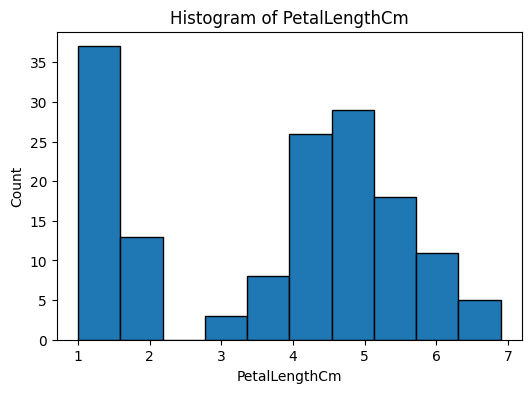

데이터가 가장 많은 구간: (0.994, 1.59] 개수: 37


In [11]:
plt.figure(figsize=(6,4))
plt.hist(df["PetalLengthCm"], bins=10, edgecolor="black")
plt.title("Histogram of PetalLengthCm")
plt.xlabel("PetalLengthCm")
plt.ylabel("Count")
plt.show()

bin_counts = pd.cut(df["PetalLengthCm"], bins=10).value_counts()
most_bin = bin_counts.idxmax()
print("데이터가 가장 많은 구간:", most_bin, "개수:", bin_counts.max())

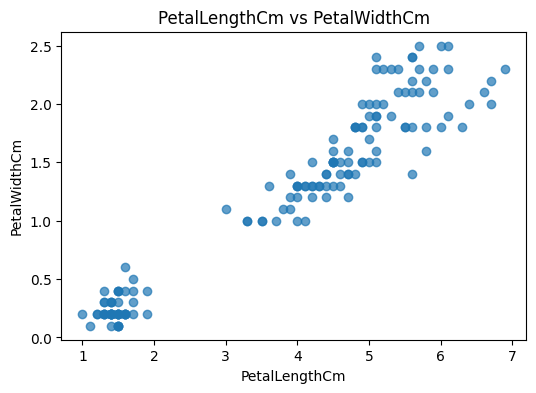

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(df["PetalLengthCm"], df["PetalWidthCm"], alpha=0.7)
plt.title("PetalLengthCm vs PetalWidthCm")
plt.xlabel("PetalLengthCm")
plt.ylabel("PetalWidthCm")
plt.show()

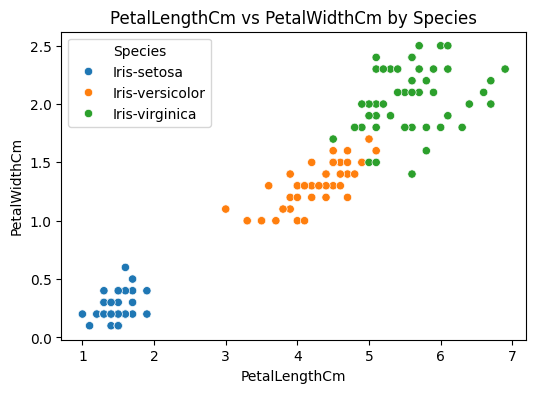

In [13]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="PetalLengthCm", y="PetalWidthCm", hue="Species")
plt.title("PetalLengthCm vs PetalWidthCm by Species")
plt.show()

In [14]:
mean_table = df.groupby("Species")[["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]].mean()
print(mean_table)

print("꽃받침이 가장 긴 종류( SepalLengthCm 평균 기준 ):", mean_table["SepalLengthCm"].idxmax())
print("꽃잎이 가장 넓은 종류( PetalWidthCm 평균 기준 ):", mean_table["PetalWidthCm"].idxmax())

                 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
Species                                                                  
Iris-setosa              5.006         3.418          1.464         0.244
Iris-versicolor          5.936         2.770          4.260         1.326
Iris-virginica           6.588         2.974          5.552         2.026
꽃받침이 가장 긴 종류( SepalLengthCm 평균 기준 ): Iris-virginica
꽃잎이 가장 넓은 종류( PetalWidthCm 평균 기준 ): Iris-virginica


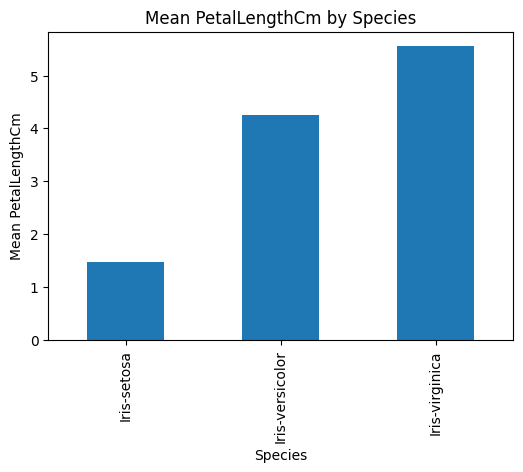

측정값별 (종 평균의 최대 - 최소):
PetalLengthCm    4.088
PetalWidthCm     1.782
SepalLengthCm    1.582
SepalWidthCm     0.648
dtype: float64
가장 큰 차이를 보이는 측정값: PetalLengthCm


In [15]:
plt.figure(figsize=(6,4))
mean_table["PetalLengthCm"].sort_values().plot(kind="bar")
plt.title("Mean PetalLengthCm by Species")
plt.ylabel("Mean PetalLengthCm")
plt.show()

diff = (mean_table.max() - mean_table.min()).sort_values(ascending=False)
print("측정값별 (종 평균의 최대 - 최소):")
print(diff)

print("가장 큰 차이를 보이는 측정값:", diff.idxmax())

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44867 (\N{HANGUL SYLLABLE GGOC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51086 (\N{HANGUL SYLLABLE IP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

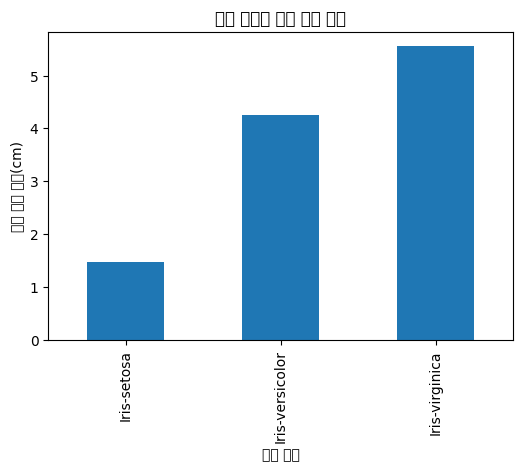

측정값별 (종 평균의 최대 - 최소) 차이:
PetalLengthCm    4.088
PetalWidthCm     1.782
SepalLengthCm    1.582
SepalWidthCm     0.648
dtype: float64
가장 큰 차이를 보이는 측정값: PetalLengthCm


In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
mean_table["PetalLengthCm"].sort_values().plot(kind="bar")

plt.title("붓꽃 종류별 평균 꽃잎 길이")
plt.xlabel("붓꽃 종류")
plt.ylabel("평균 꽃잎 길이(cm)")
plt.show()

diff = (mean_table.max() - mean_table.min()).sort_values(ascending=False)
print("측정값별 (종 평균의 최대 - 최소) 차이:")
print(diff)

print("가장 큰 차이를 보이는 측정값:", diff.idxmax())

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows
# plt.rcParams["font.family"] = "AppleGothic"   # macOS
plt.rcParams["axes.unicode_minus"] = False